# 07. Extension: does loss of the RNA exosome raise histone and lncRNA/antisense transcripts? (report Fig. 18)

Not part of the paper. Fig. S5A of the paper shows a histone gene program and a program of dysregulated
lncRNA/antisense transcripts. The lncRNA/antisense signature is the gene program of notebook 05 that best matches
the lncRNA list of the original notebook. Replication-dependent histone genes are not assigned to any program by
HDBSCAN here, so the histone signature is simply all histone (HIST*) genes expressed at >0.25 UMI/cell.
Both signatures are scored for every perturbation as in notebook 05, and the RNA exosome subunits are compared
with all other perturbations.

In [1]:
import sys; sys.path.insert(0, "../src")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from adjustText import adjust_text
from scipy.stats import mannwhitneyu
import gwps

gw = gwps.load("k562_gw")
genes = pd.read_csv(gwps.RES / "k562_gw_selected_genes.csv")["gene_id"]
prog = pd.read_csv(gwps.RES / "k562_gw_gene_programs.csv", index_col=0)["program"]
assigned = prog[prog >= 0]

original_lnc = ["ACSM3", "PNN", "CLN5", "NPRL3", "YWHAH", "CYB561A3", "MTHFD2L", "FMC1", "PCF11", "ATF7IP2", "SMIM4",
                "MAT2A", "SCAND1", "CSTF3", "EPM2AIP1", "DPM3", "ZNF708", "H1FX", "SLC39A10", "PBX2", "PPP1R10",
                "THUMPD3-AS1", "ERV3-1", "MIR17HG", "DANCR", "HCG18", "DLEU2", "SNHG3", "GABPB1-AS1", "RAB30-DT",
                "TMEM161B-AS1", "MINCR", "AP002387.2", "EID1", "SNHG19", "LINC01003", "AC004687.1", "ILF3-DT",
                "SNHG30", "ZSCAN16-AS1", "ZNF595", "PAXIP1-AS1", "SNHG4", "AC016074.2"]
v = gw.var
histone = v.loc[v["gene_name"].str.startswith("HIST") & (v["mean"] > 0.25), "gene_name"]
k_lnc = assigned[assigned.index.isin(original_lnc)].value_counts().idxmax()
signatures = {"Histone": pd.Index(histone), "lncRNA/antisense": assigned.index[assigned == k_lnc]}
for n, g in signatures.items():
    print(f"{n} program: {len(g)} genes: {', '.join(g[:20])}{' ...' if len(g) > 20 else ''}")
print(f"original lncRNA list genes in the data: {sum(prog.index.isin(original_lnc))}, "
      f"in the lncRNA/antisense program: {sum(signatures['lncRNA/antisense'].isin(original_lnc))}")

Histone program: 15 genes: HIST2H2AC, HIST3H2A, HIST1H1C, HIST1H4C, HIST1H2BC, HIST1H2AC, HIST1H1E, HIST1H1D, HIST1H2BH, HIST1H4H, HIST1H2BJ, HIST1H2AG, HIST1H2AH, HIST1H2BN, HIST1H1B
lncRNA/antisense program: 20 genes: SNHG3, MAT2A, SLC39A10, EPM2AIP1, NCBP2AS2, ZNF595, DANCR, MTHFD2L, SNHG4, PPP1R10, LINC01003, LINC00958, AP002387.2, DLEU2, MIR17HG, PNN, SNHG19, AC004687.1, ILF3-DT, YWHAH
original lncRNA list genes in the data: 35, in the lncRNA/antisense program: 18


In [2]:
pert = gw.obs.index[~gw.obs["is_control"] & (gw.obs["num_cells_filtered"] >= 25)]
expr = gwps.profiles(gw[pert])
scores = pd.DataFrame({n: expr.loc[:, expr.columns.isin(g)].mean(1) for n, g in signatures.items()})
scores = (scores - scores.mean()) / scores.std()
scores["target"] = gw.obs.loc[pert, "target"].values
exosome = ["EXOSC1", "EXOSC2", "EXOSC3", "EXOSC4", "EXOSC5", "EXOSC6", "EXOSC7", "EXOSC8", "EXOSC9", "EXOSC10", "DIS3"]
is_exo = scores["target"].isin(exosome)

rows = []
for n in signatures:
    p = mannwhitneyu(scores.loc[is_exo, n], scores.loc[~is_exo, n], alternative="greater").pvalue
    rows.append({"score": n, "exosome median z": scores.loc[is_exo, n].median(),
                 "other median z": scores.loc[~is_exo, n].median(), "one-sided Mann-Whitney p": p})
display(pd.DataFrame(rows).round(4))
scores.loc[is_exo, ["target", "Histone", "lncRNA/antisense"]].sort_values("Histone", ascending=False).round(2)

,score,exosome median z,other median z,one-sided Mann-Whitney p
0,Histone,6.7074,-0.0232,0.0
1,lncRNA/antisense,26.9699,-0.0534,0.0


,target,Histone,lncRNA/antisense
gene_transcript,,,
2793_EXOSC6_P1P2_ENSG00000223496,EXOSC6,11.47,24.760000
2792_EXOSC5_P1P2_ENSG00000077348,EXOSC5,10.50,28.430000
2790_EXOSC3_P1P2_ENSG00000107371,EXOSC3,7.26,26.969999
2233_DIS3_P1P2_ENSG00000083520,DIS3,7.06,28.950001
2791_EXOSC4_P1P2_ENSG00000178896,EXOSC4,6.80,27.830000
2789_EXOSC2_P1P2_ENSG00000130713,EXOSC2,6.71,30.379999
2795_EXOSC8_P1P2_ENSG00000120699,EXOSC8,5.64,26.980000
2796_EXOSC9_P1P2_ENSG00000123737,EXOSC9,4.58,21.000000
2788_EXOSC1_P1P2_ENSG00000171311,EXOSC1,2.40,2.510000


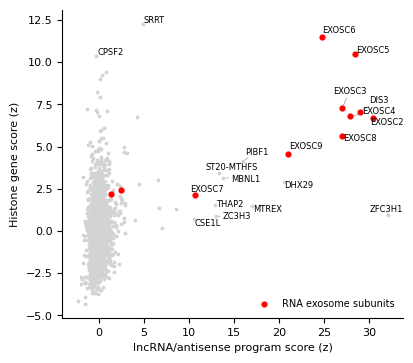

In [3]:
fig, ax = plt.subplots(figsize=(4.4, 4))
ax.scatter(scores["lncRNA/antisense"], scores["Histone"], s=3, c="lightgrey", rasterized=True)
ax.scatter(scores.loc[is_exo, "lncRNA/antisense"], scores.loc[is_exo, "Histone"], s=12, c="red", label="RNA exosome subunits")
top = (scores["Histone"] ** 2 + scores["lncRNA/antisense"] ** 2).nlargest(20).index
texts = [ax.text(scores.loc[i, "lncRNA/antisense"], scores.loc[i, "Histone"], scores.loc[i, "target"], fontsize=6)
         for i in top]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="grey", lw=0.4))
ax.set_xlabel("lncRNA/antisense program score (z)"); ax.set_ylabel("Histone gene score (z)")
ax.legend(frameon=False, loc="lower right")
gwps.savefig(fig, "fig18a_exosome_scores")

KEGG enrichment of perturbations with a high score (z > 2.5 for either program), against all scored perturbations.

193 perturbations with z > 2.5


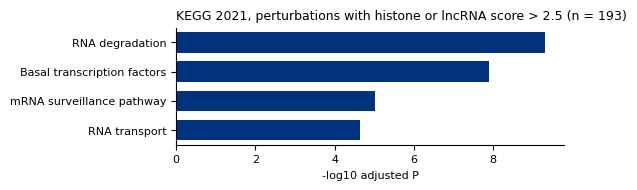

,Term,Odds Ratio,Adjusted P-value,Genes
0,RNA degradation,14.798689,4.837330e-10,DIS3;EXOSC7;EXOSC6;EXOSC5;EXOSC4;XRN1;EXOSC9;X...
1,Basal transcription factors,19.815839,1.279545e-08,TBP;TAF12;CCNH;TAF10;TAF8;TAF7;TAF6;TAF5;TAF3;...
2,mRNA surveillance pathway,8.945999,9.870751e-06,CPSF4;CPSF1;NCBP1;PABPN1;WDR82;NCBP2;RNMT;CPSF...
3,RNA transport,5.795100,2.355617e-05,NCBP1;NCBP2;GEMIN2;DDX20;PHAX;EEF1A1;CLNS1A;NU...


In [4]:
high = scores.loc[(scores["Histone"] > 2.5) | (scores["lncRNA/antisense"] > 2.5), "target"].unique()
enr = gwps.enrich(high, scores["target"].unique())
print(f"{len(high)} perturbations with z > 2.5")
gwps.enrich_barplot(enr, f"KEGG 2021, perturbations with histone or lncRNA score > 2.5 (n = {len(high)})", "fig18b_kegg_high_scores")
enr[["Term", "Odds Ratio", "Adjusted P-value", "Genes"]]